# End-to-end 2D thrust-fault prediction and post-processing

This notebook is the compact, reproducible inline-600 demonstration for the public source release. It imports the maintained UASS-Net architecture through `fault_post_processing_2d.py`, together with the canonical SEG-Y reader, patch inference, and complete 2D post-processing workflow. It has no dependency on unpublished development notebooks.

Required inputs:

- `model_real.pth` in the repository root. The reference checkpoint SHA-256 is `d154ab68869cfc9c789b94835cb2614c182c7dd0fa3fd56cf2af4bb9b2b638aa`.
- `inline600.segy` at `data/segy/inline600.segy` relative to the repository root. The reference SEG-Y SHA-256 is `87ed66c6c91839661bf4a7a765175cbd332e0922ce85d63c09b44b91539ff785`.

Launch the notebook with the kernel working directory set to either the repository root or its `demo/` directory. The first code cell discovers the repository root without relying on the clone directory name.

To retain compatible inference behavior, the decoder uses nearest-neighbor upsampling and the overlap mask preserves the original row-then-column boundary assignment. The continuous sigmoid prediction is passed directly to post-processing; it is not transposed or binarized before the 0.1 probability threshold is applied.

The downstream workflow preserves the weak ridge-support recovery, two-pass Group reduction, curvature-constrained weak adjustment, three-point angle filters, second-DBSCAN noise masking with carried labels, iterative geometric merging, post-merge size filter, and final interpolation. This demonstration uses `MIN_KEEP_RATIO = 0.98`, so its post-processing stage counts are not compared with the legacy reference stage counts. Only figure-producing cells retain notebook output. The clean and executed notebooks use identical cell sources; the executed version retains figures generated with these configured parameters.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np


def find_repository_root(start=None):
    current = Path.cwd() if start is None else Path(start)
    current = current.expanduser().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "fault_post_processing_2d.py").is_file():
            return candidate
    raise FileNotFoundError(
        "Repository root not found. Launch this notebook from the repository "
        "root or its demo directory."
    )


REPO_ROOT = find_repository_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

MODEL_WEIGHTS_FILE = REPO_ROOT / "model_real.pth"
SEISMIC_FILE = REPO_ROOT / "data" / "segy" / "inline600.segy"

REFERENCE_MODEL_SHA256 = "d154ab68869cfc9c789b94835cb2614c182c7dd0fa3fd56cf2af4bb9b2b638aa"
REFERENCE_SEISMIC_SHA256 = "87ed66c6c91839661bf4a7a765175cbd332e0922ce85d63c09b44b91539ff785"

INLINE_NUMBER = 600
CROSSLINE_STRIDE = 2
SAMPLE_STRIDE = 2
EXPECTED_PROBABILITY_SHAPE = (2080, 1001)

MODEL_BASE_CHANNELS = 16
MODEL_DROPOUT = 0.2
PREDICTION_PATCH_SHAPE = (256, 256)
PREDICTION_OVERLAP = 12
PREDICTION_DEVICE = "auto"

PROBABILITY_THRESHOLD = 0.1
GRADIENT_RATIO = 0.10
NORMAL_STEP = 1.0
RIDGE_SUPPORT_RADIUS = 8
MIN_KEEP_RATIO = 0.98
GROUP_MAX_GAP = 20

DENOISE_EPS = 10
DENOISE_MIN_SAMPLES = 5

CURVATURE_TAU = 0.5
CURVATURE_DELTA = 1e-3
CURVATURE_LOCAL_WINDOW = 7
CURVATURE_SMOOTH_WINDOW = 5
CURVATURE_BLEND_STRENGTH = 0.01
CURVATURE_MAX_SHIFT = 0.05
ANGLE_THRESHOLD = 90.0
ANGLE_MAX_ROUNDS = 10

SECOND_DBSCAN_EPS = 10
SECOND_DBSCAN_MIN_SAMPLES = 3

MERGE_THETA_MAX = 17.0
MERGE_DISTANCE_MAX = 75.0
MERGE_EXTRAPOLATION_MAX = 8.0

MIN_CLUSTER_POINTS = 30
MIN_CLUSTER_VERTICAL_RANGE = 30

PLOT_X_LIMITS = (2130, -50)
PLOT_Y_LIMITS = (1051, -50)


## Plotting utilities


In [2]:
def get_distinct_colors(n_colors, seed=42):
    color_pool = []
    for name in ("tab20", "tab20b", "tab20c", "Set3", "Paired", "Accent", "Dark2"):
        colormap = plt.get_cmap(name)
        if hasattr(colormap, "colors"):
            color_pool.extend(list(colormap.colors))
        else:
            color_pool.extend([colormap(i) for i in np.linspace(0, 1, colormap.N)])

    unique_pool = []
    seen = set()
    for color in color_pool:
        key = tuple(np.round(color, 6))
        if key not in seen:
            seen.add(key)
            unique_pool.append(color)

    rng = np.random.default_rng(seed)
    rng.shuffle(unique_pool)
    if n_colors > len(unique_pool):
        extra = n_colors - len(unique_pool)
        unique_pool.extend([plt.cm.hsv(i / extra) for i in range(extra)])
    return unique_pool[:n_colors]


def format_fault_axis(axis, title=None):
    axis.set_xlim(*PLOT_X_LIMITS)
    axis.set_ylim(*PLOT_Y_LIMITS)
    axis.tick_params(labelsize=11)
    if title:
        axis.set_title(title, fontsize=12)


def draw_points(axis, points, title=None, color="black", size=4):
    points = np.asarray(points)
    if len(points):
        axis.scatter(points[:, 0], points[:, 1], c=color, s=size, marker=".", alpha=0.8)
    format_fault_axis(axis, title)


def draw_clusters(axis, points, labels, title=None, seed=42):
    points = np.asarray(points)
    labels = np.asarray(labels)
    unique_labels = sorted(np.unique(labels).tolist())
    colors = get_distinct_colors(len(unique_labels), seed=seed)

    for cluster_label, color in zip(unique_labels, colors):
        cluster_points = points[labels == cluster_label]
        if len(cluster_points) == 0:
            continue
        axis.plot(
            cluster_points[:, 0],
            cluster_points[:, 1],
            "o",
            markerfacecolor=color,
            markeredgecolor="black",
            markeredgewidth=0.15,
            markersize=3,
            alpha=0.95,
        )
    format_fault_axis(axis, title)


## 1. Generate the inline-600 fault-probability map with UASS-Net

The UASS-Net architecture and checkpoint parser are maintained in `uassnet_model.py`. The public loader, memory-efficient SEG-Y reader, tiled inference, and 2D post-processing pipeline are exposed by `fault_post_processing_2d.py` and imported below, so the notebook does not carry private copies of those implementations.

The supplied checkpoint is loaded with strict key and shape validation. Nearest-neighbor decoder upsampling is required to reproduce the reference probability map. The SEG-Y volume contains inlines 600–602; inline 600 is selected by its header value, and the crossline and sample axes are each downsampled by two. The resulting `(2080, 1001)` section is predicted with 256 × 256 patches, 12-pixel overlap, patch-wise standardization, sigmoid activation, and Gaussian overlap blending.


In [3]:
from fault_post_processing_2d import (
    InferenceConfig,
    PostprocessConfig,
    process_single_inline,
    sha256_file,
    validate_inline600_reference,
)

inference_config = InferenceConfig(
    patch_shape=PREDICTION_PATCH_SHAPE,
    overlap=PREDICTION_OVERLAP,
)
postprocess_config = PostprocessConfig(
    probability_threshold=PROBABILITY_THRESHOLD,
    gradient_ratio=GRADIENT_RATIO,
    normal_step=NORMAL_STEP,
    ridge_support_radius=RIDGE_SUPPORT_RADIUS,
    min_keep_ratio=MIN_KEEP_RATIO,
    group_max_gap=GROUP_MAX_GAP,
    first_dbscan_eps=DENOISE_EPS,
    first_dbscan_min_samples=DENOISE_MIN_SAMPLES,
    curvature_tau=CURVATURE_TAU,
    curvature_delta=CURVATURE_DELTA,
    curvature_local_window=CURVATURE_LOCAL_WINDOW,
    curvature_smooth_window=CURVATURE_SMOOTH_WINDOW,
    curvature_blend_strength=CURVATURE_BLEND_STRENGTH,
    curvature_max_shift=CURVATURE_MAX_SHIFT,
    angle_threshold=ANGLE_THRESHOLD,
    angle_max_rounds=ANGLE_MAX_ROUNDS,
    second_dbscan_eps=SECOND_DBSCAN_EPS,
    second_dbscan_min_samples=SECOND_DBSCAN_MIN_SAMPLES,
    merge_theta_max=MERGE_THETA_MAX,
    merge_distance_max=MERGE_DISTANCE_MAX,
    merge_extrapolation_max=MERGE_EXTRAPOLATION_MAX,
    min_cluster_points=MIN_CLUSTER_POINTS,
    min_cluster_vertical_range=MIN_CLUSTER_VERTICAL_RANGE,
)


In [4]:
if not SEISMIC_FILE.is_file():
    raise FileNotFoundError(f"Seismic input not found: {SEISMIC_FILE.resolve()}")
actual_seismic_sha256 = sha256_file(SEISMIC_FILE)
if actual_seismic_sha256 != REFERENCE_SEISMIC_SHA256:
    raise ValueError(
        "SEG-Y SHA-256 mismatch: "
        f"expected {REFERENCE_SEISMIC_SHA256}, got {actual_seismic_sha256}."
    )

workflow_result = process_single_inline(
    segy_path=SEISMIC_FILE,
    weights_path=MODEL_WEIGHTS_FILE,
    inline_number=INLINE_NUMBER,
    crossline_stride=CROSSLINE_STRIDE,
    sample_stride=SAMPLE_STRIDE,
    inference_config=inference_config,
    postprocess_config=postprocess_config,
    device=PREDICTION_DEVICE,
    model_base_channels=MODEL_BASE_CHANNELS,
    model_dropout=MODEL_DROPOUT,
    expected_model_sha256=REFERENCE_MODEL_SHA256,
)
reference_validation = validate_inline600_reference(
    workflow_result,
    verify_file_hashes=True,
    verify_stage_counts=False,
)

seismic_section = workflow_result.seismic_section
seismic_normalized = workflow_result.seismic_normalized
postprocess_result = workflow_result.postprocess


In [5]:
probability_map = workflow_result.probability_map
if probability_map.shape != EXPECTED_PROBABILITY_SHAPE:
    raise ValueError(
        f"Unexpected probability-map shape {probability_map.shape}; "
        f"expected {EXPECTED_PROBABILITY_SHAPE}."
    )
if not np.isfinite(probability_map).all():
    raise ValueError("The model prediction contains non-finite values.")
if float(probability_map.min()) < 0.0 or float(probability_map.max()) > 1.0:
    raise ValueError("The sigmoid probability map must lie in [0, 1].")

candidate_mask = postprocess_result.candidate_mask
coordinates_matrix = postprocess_result.candidate_points


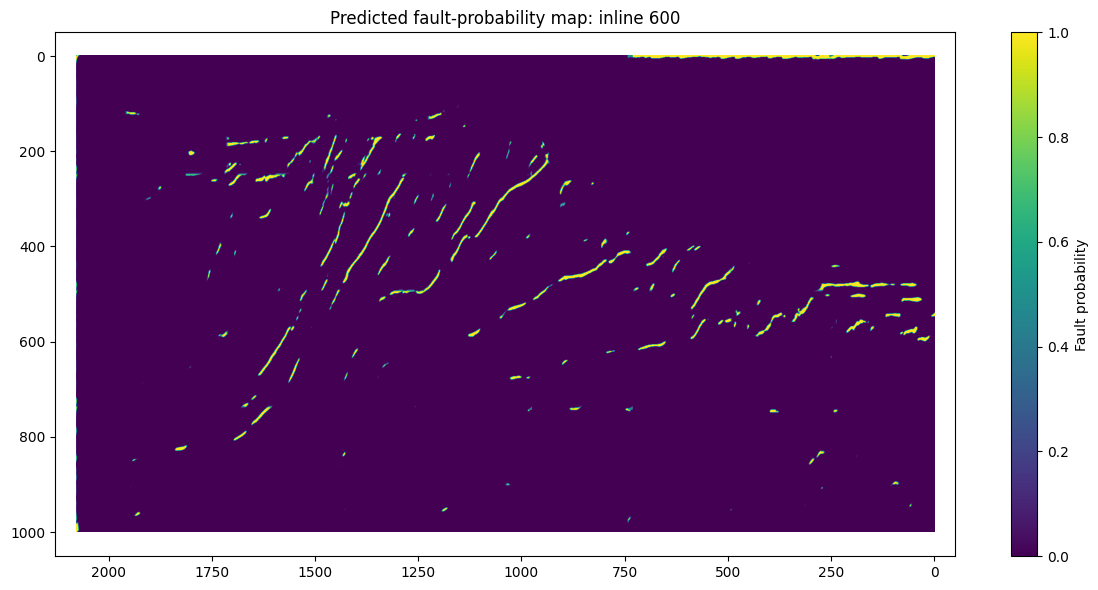

In [6]:
fig, axis = plt.subplots(figsize=(12, 6))
image = axis.imshow(
    probability_map.T,
    cmap="viridis",
    origin="upper",
    vmin=0.0,
    vmax=1.0,
    aspect="auto",
)
axis.set_xlim(*PLOT_X_LIMITS)
axis.set_ylim(*PLOT_Y_LIMITS)
axis.set_title("Predicted fault-probability map: inline 600", fontsize=12)
fig.colorbar(image, ax=axis, label="Fault probability")
fig.tight_layout()
plt.show()


## 2. Weak gradient-ridge support and legacy Group reduction

A strict ridge core is identified from local maxima sampled along the normalized gradient direction with a 10% section-wise gradient threshold. To preserve the source result, this core is used as spatial support, at least 98% of thresholded points are retained, and the original two-pass Group reduction is applied.


In [7]:
ridge_core_mask = postprocess_result.ridge_core_mask
ridge_core_points = postprocess_result.ridge_core_points
weak_ridge_mask = postprocess_result.ridge_preserved_mask
ridge_preserved_points = postprocess_result.ridge_preserved_points
group_f_points = postprocess_result.grouped_points
ridge_diagnostics = postprocess_result.diagnostics["ridge"]
weak_ridge_diagnostics = postprocess_result.diagnostics["ridge_preservation"]


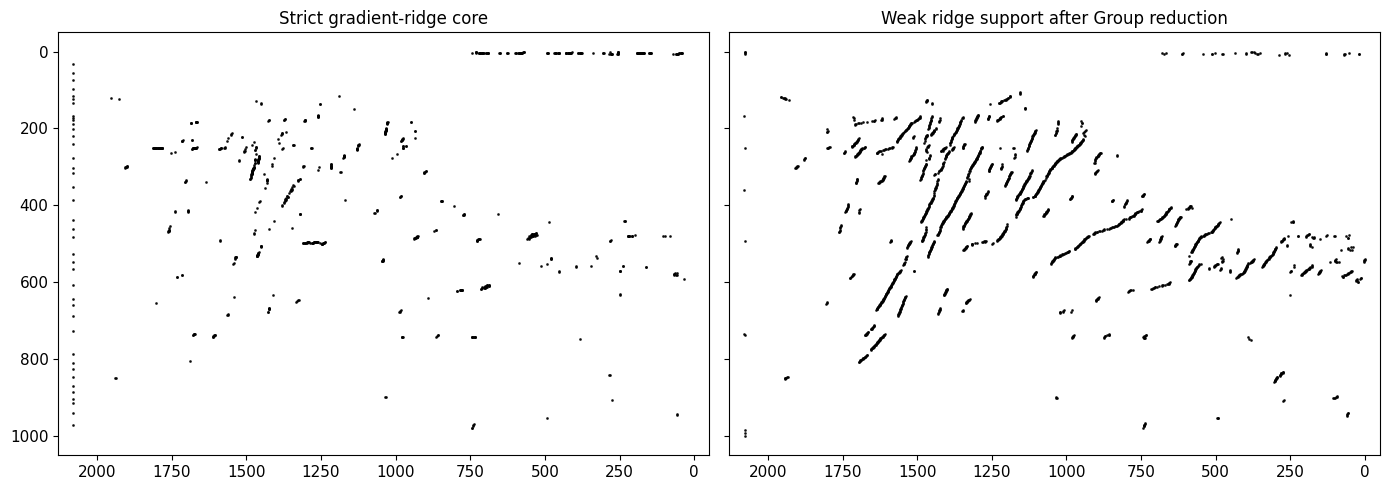

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
draw_points(axes[0], ridge_core_points, "Strict gradient-ridge core")
draw_points(axes[1], group_f_points, "Weak ridge support after Group reduction")
fig.tight_layout()
plt.show()


## 3. Density-based removal of isolated ridge points


In [9]:
density_labels = postprocess_result.first_dbscan_raw_labels
density_mask = density_labels != -1
DBS_data = postprocess_result.first_dbscan_points
DBS_labels = postprocess_result.first_dbscan_labels


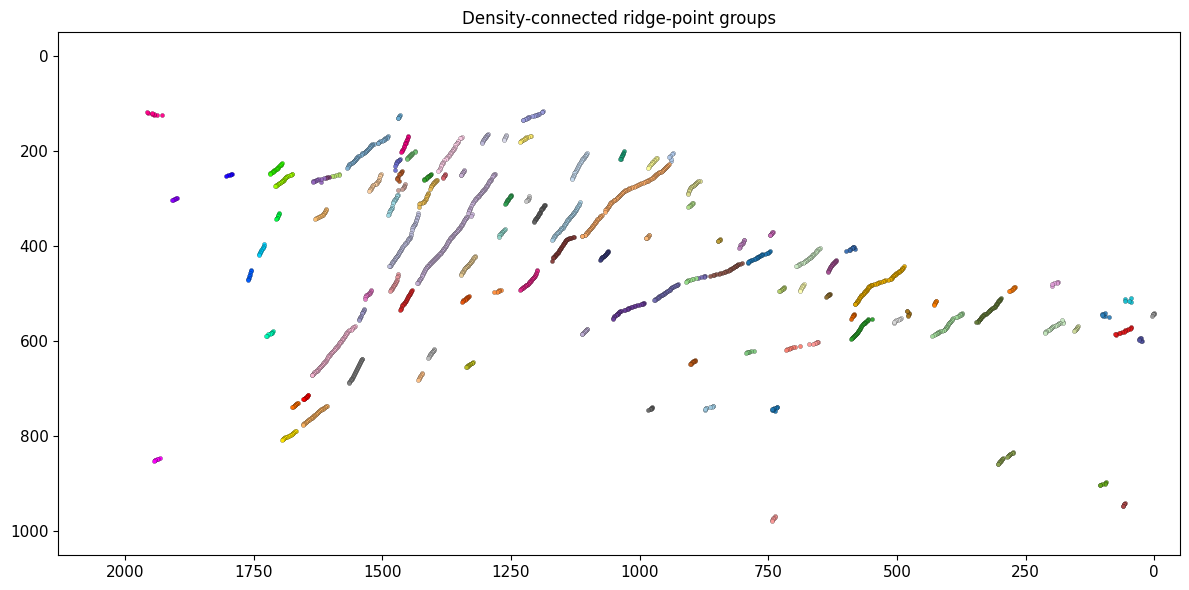

In [10]:
fig, axis = plt.subplots(figsize=(12, 6))
draw_clusters(axis, DBS_data, DBS_labels, "Density-connected ridge-point groups")
fig.tight_layout()
plt.show()


## 4. Weak curvature-constrained adjustment and legacy angle filtering

Within each density-connected group, points are ordered by the dominant PCA direction, parameterized by cumulative arc length, and evaluated with the curvature-deviation ratio. Points with a ratio greater than 0.5 move 1% toward a five-point moving-average target, with displacement capped at 0.05 pixel. The source notebook's three-point angle filter is then applied unchanged.


In [11]:
curvature_data = postprocess_result.first_curvature_points
curvature_labels = postprocess_result.first_curvature_labels
curvature_summary = postprocess_result.diagnostics["first_curvature"]
break_data = postprocess_result.first_angle_points
break_labels = postprocess_result.first_angle_labels
angle_summary = postprocess_result.diagnostics["first_angle"]


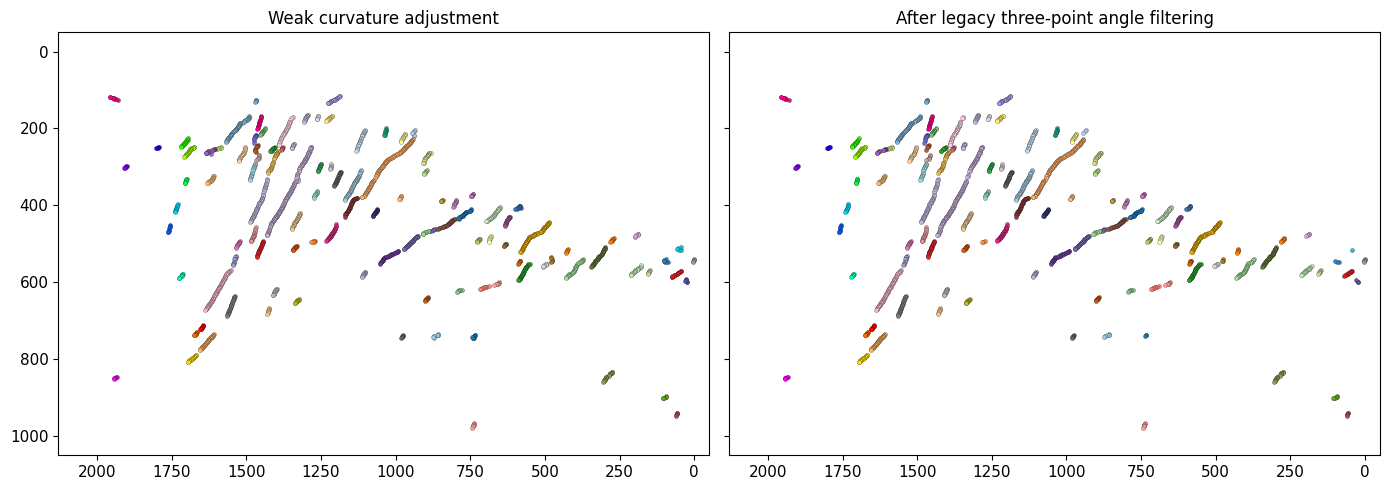

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
draw_clusters(axes[0], curvature_data, curvature_labels, "Weak curvature adjustment")
draw_clusters(axes[1], break_data, break_labels, "After legacy three-point angle filtering")
fig.tight_layout()
plt.show()


## 5. Second DBSCAN noise mask

This cell deliberately preserves the source notebook's behavior: the second DBSCAN identifies its noise mask, while the surviving points retain the labels carried from the first DBSCAN stage.


In [13]:
second_dbscan_labels = postprocess_result.second_dbscan_raw_labels
second_density_mask = postprocess_result.second_dbscan_keep_mask
DBS_data2 = postprocess_result.second_dbscan_points
DBS_labels2 = postprocess_result.second_dbscan_carried_labels


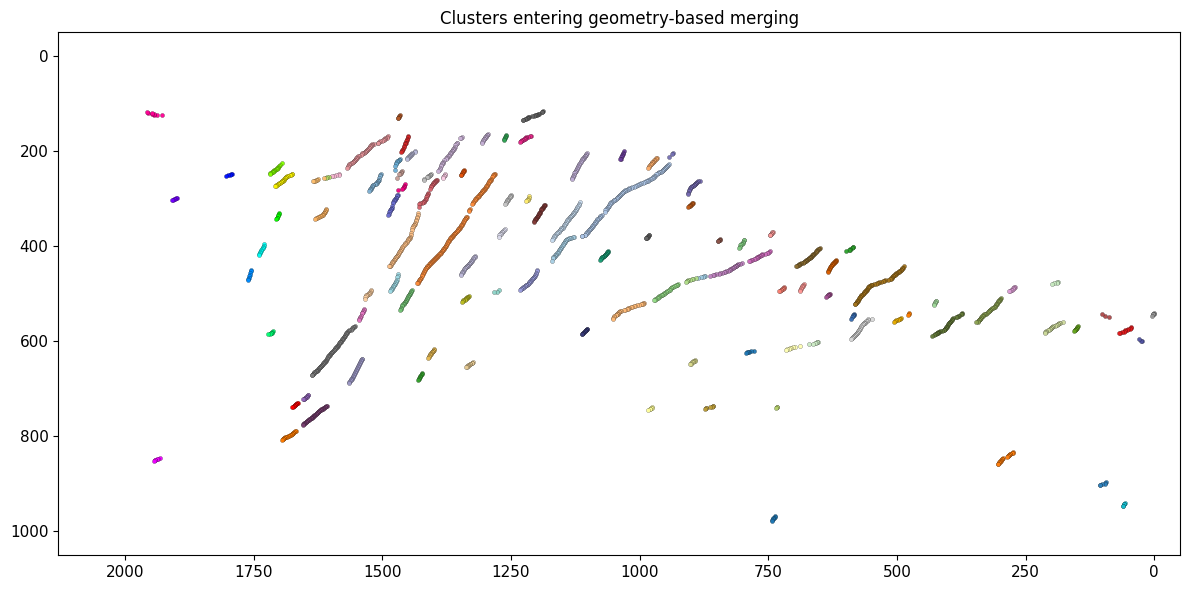

In [14]:
fig, axis = plt.subplots(figsize=(12, 6))
draw_clusters(axis, DBS_data2, DBS_labels2, "Clusters entering geometry-based merging")
fig.tight_layout()
plt.show()


## 6. Iterative geometry-consistent cluster merging

Every current cluster is represented by its centroid and PCA axis. A pair is merged only when its axial-angle difference, all-point minimum distance, and directional mean extrapolation distance simultaneously satisfy the selected thresholds. Cluster geometry is recomputed after every batch of merges until convergence.

The manuscript reference values are 15 degrees, 75 pixels, and 5 pixels. The source notebook uses the calibrated in-range values 17 degrees, 75 pixels, and 8 pixels to preserve its legacy output.


In [15]:
merged_labels = postprocess_result.merged_labels
paper_merge_summary = postprocess_result.diagnostics["merge"]
unique_merged_labels = np.unique(merged_labels)
n_merged_clusters = len(unique_merged_labels)


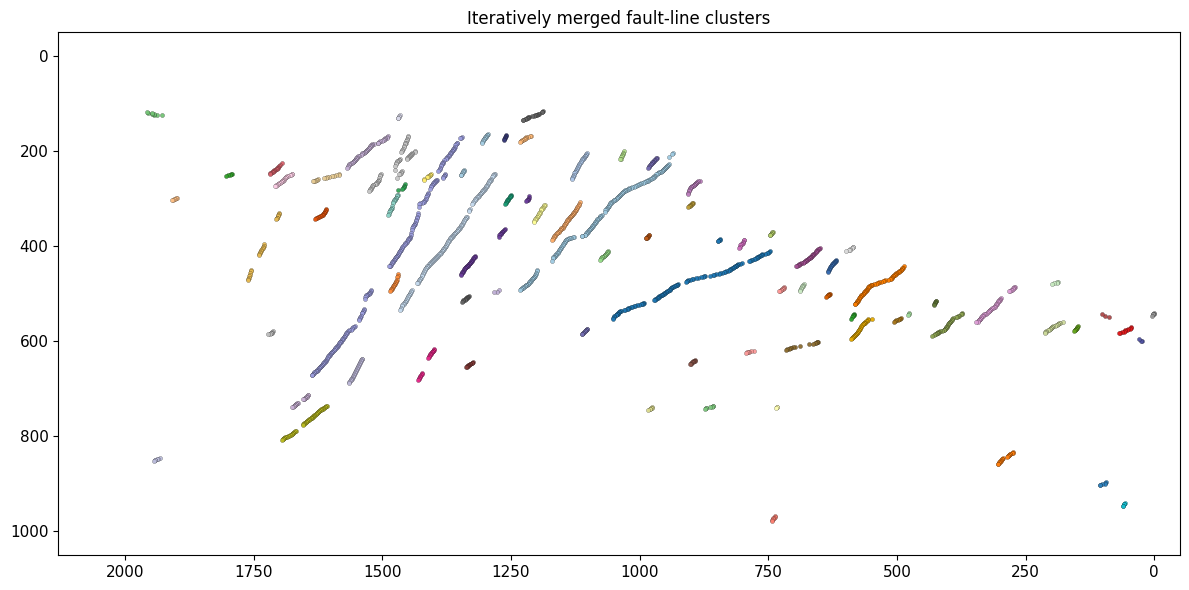

In [16]:
fig, axis = plt.subplots(figsize=(12, 6))
draw_clusters(axis, DBS_data2, merged_labels, "Iteratively merged fault-line clusters")
fig.tight_layout()
plt.show()


## 7. Large-cluster selection and repeated geometry cleanup

The source notebook retains clusters with at least 30 points and a vertical range greater than 30 pixels. The same weak curvature adjustment and three-point angle filter are then applied a second time without changing their parameters.


In [17]:
big_clusters = postprocess_result.large_clusters
big_data = postprocess_result.large_cluster_points
big_labels = postprocess_result.large_cluster_labels
unique_big_labels = np.unique(big_labels)

big_curvature_data = postprocess_result.second_curvature_points
big_curvature_labels = postprocess_result.second_curvature_labels
big_curvature_summary = postprocess_result.diagnostics["second_curvature"]
break_data2 = postprocess_result.second_angle_points
break_labels2 = postprocess_result.second_angle_labels
angle_summary2 = postprocess_result.diagnostics["second_angle"]


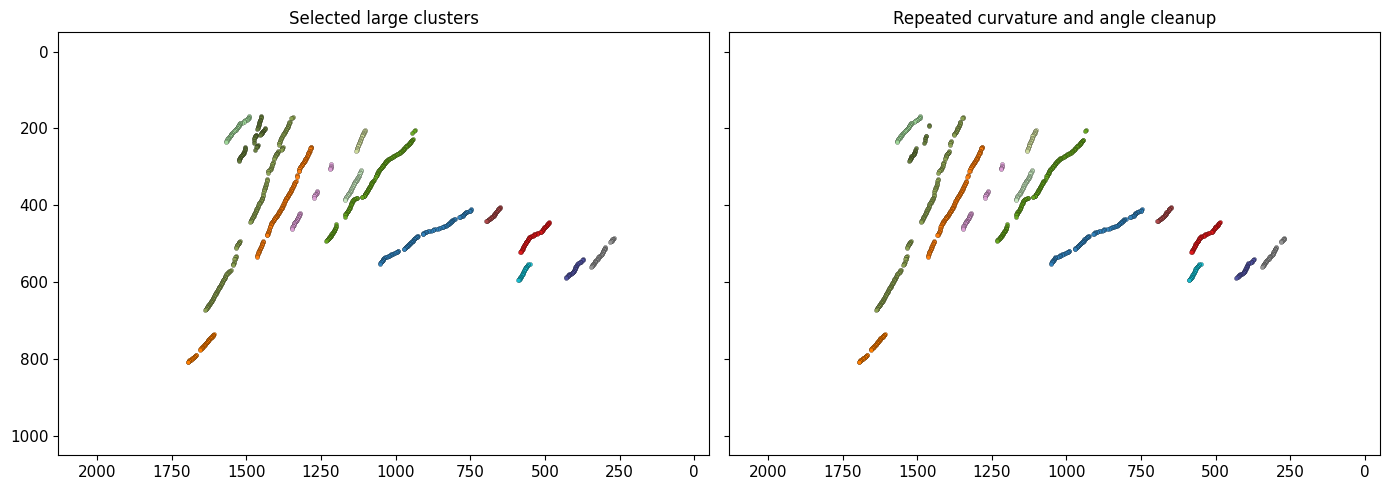

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
draw_clusters(axes[0], big_data, big_labels, "Selected large clusters")
draw_clusters(axes[1], break_data2, break_labels2, "Repeated curvature and angle cleanup")
fig.tight_layout()
plt.show()


## 8. Linear interpolation of the final 2D fault traces


In [19]:
interpolated_clusters = postprocess_result.interpolated_clusters
interpolated_points_numpy = postprocess_result.interpolated_points
interpolated_labels_numpy = postprocess_result.interpolated_labels

assert reference_validation["validated"] is True


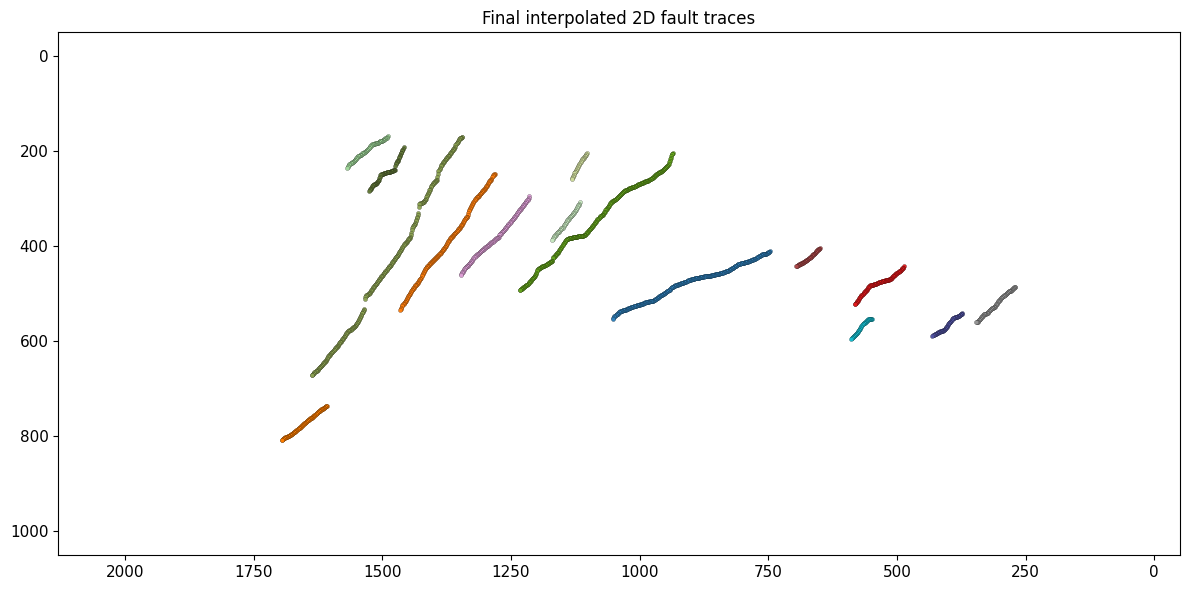

In [20]:
fig, axis = plt.subplots(figsize=(12, 6))
draw_clusters(
    axis,
    interpolated_points_numpy,
    interpolated_labels_numpy,
    "Final interpolated 2D fault traces",
)
fig.tight_layout()
plt.show()


## 9. Final fault traces overlaid on the inference seismic section

The background below is the same normalized inline-600 section used to generate the UASS-Net probability map.

In [21]:
if seismic_normalized.shape != probability_map.shape:
    raise ValueError(
        "The seismic section and predicted probability map must have the same shape."
    )


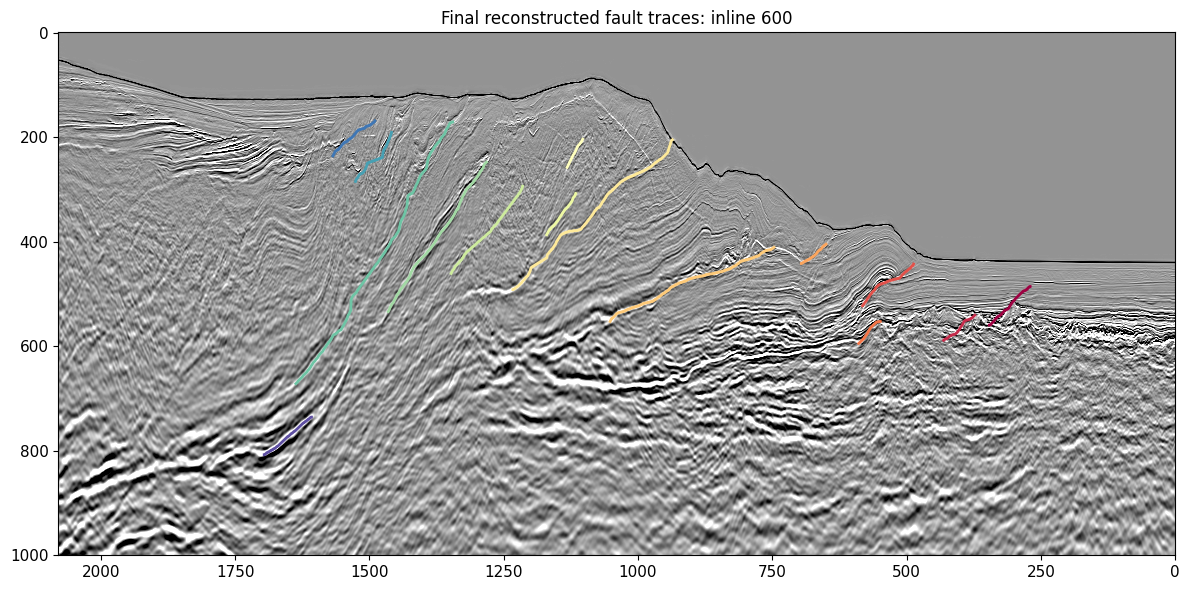

In [22]:
fig, axis = plt.subplots(figsize=(12, 6))
axis.imshow(
    seismic_normalized.T,
    cmap="gray",
    vmin=0.44,
    vmax=0.54,
    origin="upper",
    aspect="auto",
)
colors = [
    plt.cm.Spectral(value)
    for value in np.linspace(0, 1, len(interpolated_clusters))
]
for (cluster_label, cluster_points), color in zip(interpolated_clusters.items(), colors):
    axis.plot(
        cluster_points[:, 0],
        cluster_points[:, 1],
        "-",
        color=color,
        linewidth=2,
    )
axis.invert_xaxis()
axis.set_title("Final reconstructed fault traces: inline 600", fontsize=12)
axis.tick_params(labelsize=11)
fig.tight_layout()
plt.show()
